# Satellite Coordination

Airborne campaigns often need to coordinate with satellite overpasses for calibration,
validation, or synergistic science. This notebook demonstrates how to use HyPlan's
satellite module to:

1. Browse the satellite registry
2. Compute satellite ground tracks
3. Find overpasses over a study region
4. Compute overlap between flight plans and satellite swaths

**Note:** Satellite functions require internet access to fetch TLE data from CelesTrak.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta
from shapely.geometry import box
import geopandas as gpd

from hyplan.satellites import (
    SATELLITE_REGISTRY,
    get_satellite,
    compute_ground_track,
    compute_swath_footprint,
    find_overpasses,
    find_all_overpasses,
)
from hyplan.flight_line import FlightLine
from hyplan.units import ureg

## 1. Satellite Registry

HyPlan includes a registry of common Earth-observing satellites with their
NORAD IDs, swath widths, and other metadata.

In [2]:
rows = []
for name, sat in sorted(SATELLITE_REGISTRY.items()):
    rows.append({
        "Name": sat.name,
        "NORAD ID": sat.norad_id,
        "Swath Width (km)": sat.swath_width_km,
        "Max SZA (deg)": sat.max_sza,
        "CelesTrak Group": sat.celestrak_group,
    })

sat_df = pd.DataFrame(rows)
sat_df

,Name,NORAD ID,Swath Width (km),Max SZA (deg),CelesTrak Group
0,Aqua,27424,2330.0,90.0,earth-observation
1,CALIPSO,29108,0.1,180.0,earth-observation
2,CloudSat,29107,1.4,180.0,earth-observation
3,EarthCARE,60313,150.0,180.0,earth-observation
4,ICESat-2,43613,6.5,180.0,earth-observation
5,JPSS-1 (NOAA-20),43013,3000.0,90.0,noaa
6,JPSS-2 (NOAA-21),54234,3000.0,90.0,noaa
7,Landsat-8,39084,185.0,75.0,resource
8,Landsat-9,49260,185.0,75.0,resource
9,PACE,58927,2663.0,75.0,earth-observation


## 2. Compute a Ground Track

Propagate a satellite's orbit using its TLE to compute the sub-satellite ground track
over a time window.

In [3]:
# Compute PACE ground track for a 2-hour window
start = datetime(2025, 7, 15, 17, 0, tzinfo=timezone.utc)
end = start + timedelta(hours=2)

track_gdf = compute_ground_track("PACE", start, end, time_step_s=30)
print(f"Ground track: {len(track_gdf)} points")
track_gdf.head()

Ground track: 241 points


,satellite_name,norad_id,timestamp,latitude,longitude,altitude_km,solar_zenith,geometry
0,PACE,58927,2025-07-15 17:00:00+00:00,71.269422,54.702682,510.364384,80.658909,POINT (54.70268 71.26942)
1,PACE,58927,2025-07-15 17:00:30+00:00,72.995421,52.022425,510.755426,78.950903,POINT (52.02242 72.99542)
2,PACE,58927,2025-07-15 17:01:00+00:00,74.682244,48.791584,511.117038,77.242105,POINT (48.79158 74.68224)
3,PACE,58927,2025-07-15 17:01:30+00:00,76.315610,44.827022,511.447887,75.533908,POINT (44.82702 76.31561)
4,PACE,58927,2025-07-15 17:02:00+00:00,77.874112,39.872197,511.746787,73.827319,POINT (39.8722 77.87411)


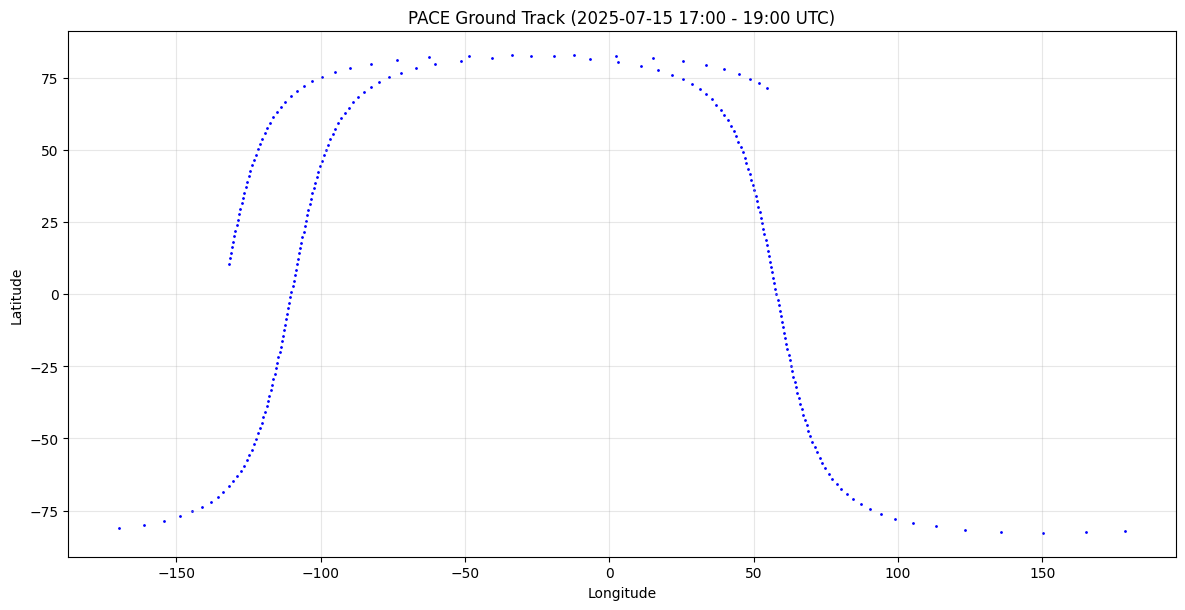

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
track_gdf.plot(ax=ax, markersize=1, color="blue")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"PACE Ground Track ({start.strftime('%Y-%m-%d %H:%M')} - {end.strftime('%H:%M UTC')})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Find Overpasses Over a Study Region

Search for satellite passes that cross a geographic bounding box within a time window.

In [5]:
# Define study region: Santa Barbara Channel
region = box(-120.5, 34.0, -119.0, 34.5)

# Search for PACE overpasses over 3 days
search_start = datetime(2025, 7, 15, 0, 0, tzinfo=timezone.utc)
search_end = search_start + timedelta(days=3)

overpasses = find_overpasses(
    satellite="PACE",
    region=region,
    start_time=search_start,
    end_time=search_end,
    include_swath=True,
)
print(f"Found {len(overpasses)} PACE overpass(es)")
if len(overpasses) > 0:
    overpasses[["satellite_name", "pass_start", "pass_end", "ascending"]]

Found 6 PACE overpass(es)


## 4. Multi-Satellite Search

Search for overpasses from multiple satellites simultaneously.

In [6]:
satellites = ["PACE", "Landsat-8", "Landsat-9", "Sentinel-2A", "Sentinel-2B"]

all_overpasses = find_all_overpasses(
    satellites=satellites,
    region=region,
    start_time=search_start,
    end_time=search_start + timedelta(days=7),
)

print(f"Found {len(all_overpasses)} total overpass(es) across {len(satellites)} satellites")
if len(all_overpasses) > 0:
    all_overpasses[["satellite_name", "pass_start", "pass_end"]].sort_values("pass_start")

Found 18 total overpass(es) across 5 satellites


## 5. Visualize Overpasses

Plot the study region with any detected satellite swath footprints.

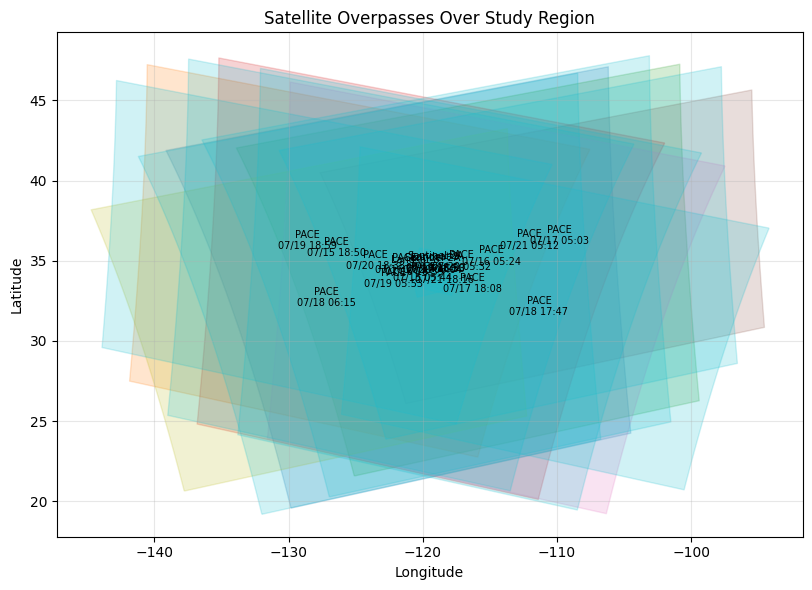

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot study region
gpd.GeoDataFrame(geometry=[region], crs="EPSG:4326").plot(
    ax=ax, facecolor="lightblue", edgecolor="black", linewidth=2, alpha=0.3, label="Study Region"
)

# Plot overpass swaths if any found
if len(all_overpasses) > 0 and "geometry" in all_overpasses.columns:
    colors = plt.cm.tab10(range(len(all_overpasses)))
    for i, (_, row) in enumerate(all_overpasses.iterrows()):
        if row.geometry is not None:
            gpd.GeoDataFrame(geometry=[row.geometry], crs="EPSG:4326").plot(
                ax=ax, facecolor=colors[i], alpha=0.2, edgecolor=colors[i]
            )
            centroid = row.geometry.centroid
            ax.annotate(
                f"{row['satellite_name']}\n{row['pass_start'].strftime('%m/%d %H:%M')}",
                xy=(centroid.x, centroid.y), fontsize=7, ha="center"
            )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Satellite Overpasses Over Study Region")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()